In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [92]:
data = pd.read_csv("m41.csv")
data.columns

Index(['solution_id', 'source_id', 'ra', 'ra_error', 'dec', 'dec_error',
       'parallax', 'parallax_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'phot_g_mean_mag', 'phot_bp_mean_mag',
       'phot_rp_mean_mag', 'target_id', 'target_ra', 'target_dec',
       'target_parallax', 'target_pm_ra', 'target_pm_dec',
       'target_radial_velocity', 'epoch', 'target_separation (deg)'],
      dtype='str')

Text(0.5, 0, 'Movimiento propio en ascensión recta')

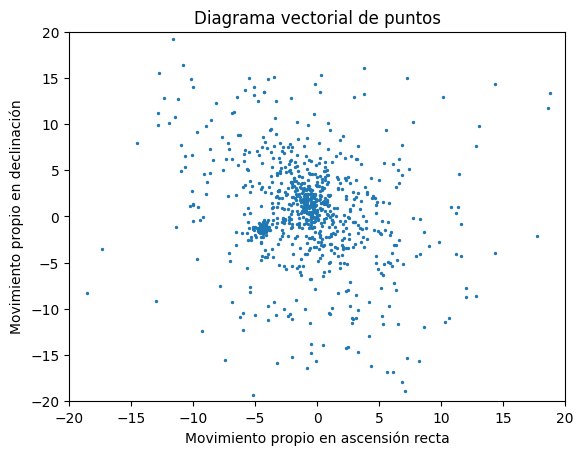

In [93]:
plt.scatter(data["pmra"], data["pmdec"], s=2)
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.title("Diagrama vectorial de puntos")
plt.ylabel("Movimiento propio en declinación")
plt.xlabel("Movimiento propio en ascensión recta")

In [94]:
VPD = data[["pmra","pmdec"]].to_numpy()
VPD_error = data[["pmra_error","pmdec_error"]].to_numpy()

In [95]:
nc0 = 0.3155386081982841
nf0 = 1 - nc0

gm = GaussianMixture(n_components=2, random_state=0,weights_init=[nc0, nf0], covariance_type="full").fit(VPD)

In [96]:
# Extraer parámetros del GMM
weights = gm.weights_
means = gm.means_
covs = gm.covariances_

# Identificar cúmulo como el más compacto
det_cov = [np.linalg.det(c) for c in covs]
cluster_idx = np.argmin(det_cov)
field_idx = np.argmax(det_cov)

# ---- CÚMULO ----
Sigma_c = covs[cluster_idx]

mu_c_ra, mu_c_dec = means[cluster_idx]
sigma_c_ra = np.sqrt(Sigma_c[0,0])
sigma_c_dec = np.sqrt(Sigma_c[1,1])
sigma_c = np.sqrt((sigma_c_ra**2 + sigma_c_dec**2)/2)
n_c = weights[cluster_idx]

# ---- CAMPO ----
Sigma_f = covs[field_idx]

mu_f_ra, mu_f_dec = means[field_idx]
sigma_f_ra = np.sqrt(Sigma_f[0,0])
sigma_f_dec = np.sqrt(Sigma_f[1,1])
cov_f = Sigma_f[0,1]
rho_f = cov_f / (sigma_f_ra * sigma_f_dec)
n_f = weights[field_idx]

# ---- Construir tabla ----
tabla = pd.DataFrame({
    "Parámetro": [
        "mu_c_ra",
        "mu_c_dec",
        "sigma_c",
        "mu_f_ra",
        "mu_f_dec",
        "sigma_f_ra",
        "sigma_f_dec",
        "rho_f",
        "n_c",
        "n_f"
    ],
    "Valor": [
        mu_c_ra,
        mu_c_dec,
        sigma_c,
        mu_f_ra,
        mu_f_dec,
        sigma_f_ra,
        sigma_f_dec,
        rho_f,
        n_c,
        n_f
    ]
})

print(tabla)

     Parámetro     Valor
0      mu_c_ra -4.381325
1     mu_c_dec -1.353807
2      sigma_c  0.170317
3      mu_f_ra -0.551628
4     mu_f_dec  0.371328
5   sigma_f_ra  4.880848
6  sigma_f_dec  6.727294
7        rho_f -0.271724
8          n_c  0.303170
9          n_f  0.696830


In [97]:
# Obtener probabilidades
probs = gm.predict_proba(VPD)

# Identificar cuál componente es el cúmulo (el más compacto)
det_cov = [np.linalg.det(c) for c in gm.covariances_]
cluster_idx = np.argmin(det_cov)

# Probabilidad de pertenencia al cúmulo
P_cluster = probs[:, cluster_idx]


In [98]:
P_threshold=0.7

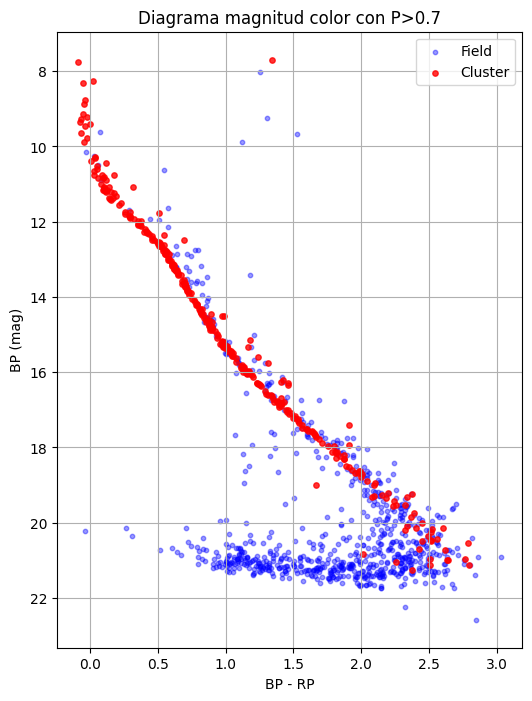

In [99]:
# ----- Definir color y magnitud -----
color = data["phot_bp_mean_mag"] - data["phot_rp_mean_mag"]
mag = data["phot_bp_mean_mag"]

# ----- Separar por probabilidad -----
cluster_mask = P_cluster > P_threshold

color_cluster = color[cluster_mask]
mag_cluster = mag[cluster_mask]

color_field = color[~cluster_mask]
mag_field = mag[~cluster_mask]

# ----- Graficar CMD -----
plt.figure(figsize=(6,8))

plt.scatter(color_field, mag_field,
            s=10, color="blue", alpha=0.4, label="Field")

plt.scatter(color_cluster, mag_cluster,
            s=15, color="red", alpha=0.8, label="Cluster")

plt.xlabel("BP - RP")
plt.ylabel("BP (mag)")
plt.title(f"Diagrama magnitud color con P>{P_threshold:.1f}")
plt.legend()

# Invertir eje Y (importante en magnitudes)
plt.gca().invert_yaxis()

plt.grid(True)
plt.show()

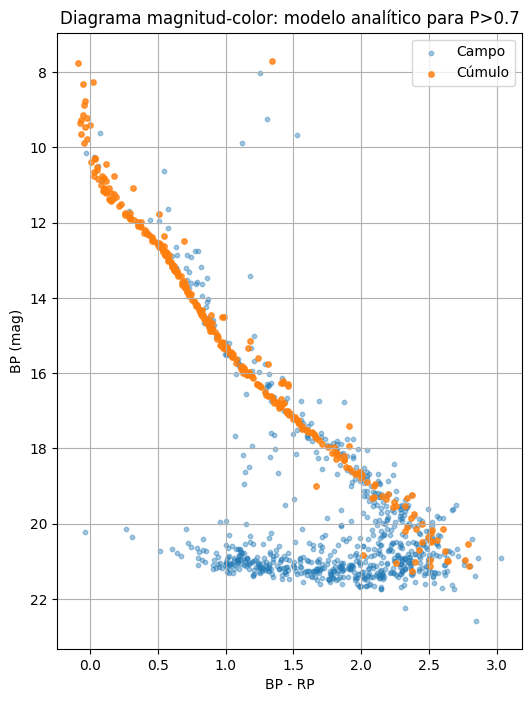

In [100]:
# ==========================
# MODELO ANALÍTICO
# ==========================

f_cluster = 0.3155386081982841 #Este es un guess obtenido con TOPCAT

# Extraer datos
pmra = data["pmra"].values
pmdec = data["pmdec"].values

# --- Cluster: gaussiana circular ---
phi_c = (1 / (2 * np.pi * sigma_c**2)) * np.exp(
    -((pmra - mu_c_ra)**2 + (pmdec - mu_c_dec)**2) / (2 * sigma_c**2)
)

# --- Campo: gaussiana elíptica con correlación ---
A = 1 / (2 * np.pi * sigma_f_ra * sigma_f_dec * np.sqrt(1 - rho_f**2))

X = (pmra - mu_f_ra) / sigma_f_ra
Y = (pmdec - mu_f_dec) / sigma_f_dec

phi_f = A * np.exp(
    -1/(2*(1 - rho_f**2)) *
    (X**2 - 2*rho_f*X*Y + Y**2)
)

# Probabilidad
P_old = (f_cluster * phi_c) / (
    f_cluster * phi_c + (1 - f_cluster) * phi_f
)

# Graficar

color = data["phot_bp_mean_mag"] - data["phot_rp_mean_mag"]
mag = data["phot_bp_mean_mag"]

mask_old = P_old > P_threshold

plt.figure(figsize=(6,8))

plt.scatter(color[~mask_old], mag[~mask_old],
            s=10, alpha=0.4, label="Campo")

plt.scatter(color[mask_old], mag[mask_old],
            s=15, alpha=0.8, label="Cúmulo")

plt.xlabel("BP - RP")
plt.ylabel("BP (mag)")
plt.title(f"Diagrama magnitud-color: modelo analítico para P>{P_threshold:.1f}")
plt.legend()
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()